# GLM-HMM Ver.4（試行単位）

`docs/requirements_ver4.md` の実装。1行 = 定義された1試行。時間ビン版（Ver.3 / ノート `10`–`12`）とは単位が違う。

**このノートで学習する2モデル**（どちらも状態数 **K=3**）

| モデル | 入力 | 内容 |
| :--- | :--- | :--- |
| 行動 4 次元 | Bias, Stimulus, Action History, Reward History | 要件 4.2 どおり |
| 顔つき 13 次元 | 上記 4 + 顔/身体 9 | ノート `12` と同じ部位（耳・目・鼻・顎の位置と速度、瞳孔） |

表情 9 次元は、各試行ウィンドウ内で集約（位置・瞳孔は中央値、速度は平均）し、セッション内で z-score したあと **1試行ラグ** する（当該試行の行動が顔特徴に漏れないように）。NWB が無いセッションでは 13 次元学習をスキップする。


## 実装上の既定値

要件に幅がある箇所は、次で進めている。変えたければ次セルの定数を書き換える。

| 項目 | 既定 | 理由 |
| :--- | :--- | :--- |
| $\alpha_{act}$ | 0.65 | 要件レンジ 0.5–0.8 の中央付近 |
| $\alpha_{rew}$ | 0.80 | 要件レンジ 0.7–0.9 の中央付近 |
| 学習対象 | 1個体の全日（既定 `VG1GC-66`） | ノート `11`/`12` と同じ個体。各日を ssm の1系列にする |
| 公式音試行 | NWB `trials`、無ければ CSV の `trial_outcome` | success→Success、miss→Short Pull、failure→No Reaction |
| Second Pull | 同じ音提示（`state_task=1`）内の2回目以降の onset | 報酬フェーズ（`state_task=2`）の引きは Success 窓に含め、独立試行にはしない |
| No Sound Pull | 整形後 onset のうち `state_task=0` | 報酬フェーズの onset は除外 |
| 正則化 | MAP `prior_sigma=2.0` | ノート `11`/`12` と同じ。13 次元で重みが暴れないように |

30 Hz のギャップ埋め・短引き除去と、報酬の `merge_asof`（tolerance ≈ 1 フレーム）は Ver.3 と同じ。ビニングと ITI カットはしない。


In [32]:
# ===================================================================
# 共通セットアップセル (ローカル / Colab 共通)
# ===================================================================
import sys
import os
from pathlib import Path

# --- 1. 環境判別 ---
IN_COLAB = False
try:
    # Colab環境でのみインポートが成功する
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass # ローカル環境


if IN_COLAB:
    # ==================================
    # Colab 環境でのセットアップ
    # ==================================
    print("環境: Colab を検出。セットアップを開始します。")

    # 1. Google Driveのマウント
    drive.mount('/content/drive')

    # 2. GitHubリポジトリのクローンまたはプル
    repo_path = Path('/content/braidyn-bc')
    if repo_path.exists():
        print("リポジトリを pull します...")
        os.chdir(repo_path)
        !git pull
    else:
        print("リポジトリを clone します...")
        !git clone https://github.com/nyaamikeneko/braidyn-bc.git
        os.chdir(repo_path)

    # 3. 依存ライブラリのインストール
    print("依存ライブラリをインストールします...")
    !pip install -q pynwb git+https://github.com/BraiDyn-BC/bdbc-nwb-explorer.git

    # 4. sys.path の設定
    project_root = repo_path
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

    print(f"セットアップ完了。プロジェクトルート: {project_root}")

else:
    # ==================================
    # ローカル (VSCode) 環境でのセットアップ
    # ==================================
    print("環境: ローカル (VSCode) を検出。")

    # 1. sys.path の設定
    current_dir = Path.cwd()
    if current_dir.name == 'notebooks':
        # ノートブックが notebooks/ から実行された場合
        project_root = current_dir.parent
    else:
        # プロジェクトルート (braidyn-bc/) から実行されたと仮定
        project_root = current_dir

    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

    print(f"プロジェクトルート: {project_root}")

# ===================================================================
# 共通インポート・処理
# (セットアップが完了したため、config.py や src/ が読み込める)
# ===================================================================
print("\n共通モジュールをインポートします...")

import bdbc_nwb_explorer as nwbx
import src.data_loader as dl
import config  # config.py もここで読み込める

print(f"データパス (DATA_NWB_ROOT): {config.DATA_NWB_ROOT}")
print(f"データパス (DATA_CSV_ROOT): {config.DATA_CSV_ROOT}")


環境: Colab を検出。セットアップを開始します。
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
リポジトリを pull します...
Already up to date.
依存ライブラリをインストールします...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
セットアップ完了。プロジェクトルート: /content/braidyn-bc

共通モジュールをインポートします...
データパス (DATA_NWB_ROOT): /content/drive/MyDrive/braidyn-bc/data
データパス (DATA_CSV_ROOT): /content/drive/MyDrive/hackathon_data


In [33]:
# ssm（lindermanlab）が無ければ入れる。Windows ではビルドに失敗することがある。
try:
    import ssm
    print("ssm:", ssm.__file__)
except ImportError:
    print("ssm が見つからないのでインストールを試みます...")
    import subprocess, sys as _sys
    subprocess.check_call([_sys.executable, "-m", "pip", "install", "-q", "cython"])
    subprocess.check_call([_sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/lindermanlab/ssm"])
    import ssm
    print("ssm installed:", ssm.__file__)


ssm: /usr/local/lib/python3.12/dist-packages/ssm/__init__.py


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.glmhmm_ver4 as v4

# 共有Driveのデータが消えたため、手元で取得したNWBを別フォルダから読む。
# NWB_ROOT_OVERRIDE を None にすれば config.py 既定の DATA_NWB_ROOT に戻る。
NWB_ROOT_OVERRIDE = "/content/drive/MyDrive/nwb_manual"
if NWB_ROOT_OVERRIDE:
    config.DATA_NWB_ROOT = Path(NWB_ROOT_OVERRIDE)
print("NWB探索先 (DATA_NWB_ROOT):", config.DATA_NWB_ROOT)

MOUSE_ID = "VG1GC-66"
INSPECT_DAY = "task-day15"   # 可視化用の代表日（ノート 10–12 と同じ）
NUM_STATES = 3
ALPHA_ACT = v4.ALPHA_ACT     # 0.65
ALPHA_REW = v4.ALPHA_REW     # 0.80
PRIOR_SIGMA = v4.PRIOR_SIGMA
SEEDS = [0, 1, 2]
NUM_ITERS = 200

print(f"mouse={MOUSE_ID}  inspect_day={INSPECT_DAY}")
print(f"K={NUM_STATES}  alpha_act={ALPHA_ACT}  alpha_rew={ALPHA_REW}")
print("available days:", v4.list_task_days(MOUSE_ID))

NWB探索先 (DATA_NWB_ROOT): /content/drive/MyDrive/nwb_manual
mouse=VG1GC-66  inspect_day=task-day15
K=3  alpha_act=0.65  alpha_rew=0.8
available days: ['task-day1', 'task-day3', 'task-day4', 'task-day5', 'task-day6', 'task-day7', 'task-day8', 'task-day9', 'task-day10', 'task-day11', 'task-day12', 'task-day13', 'task-day14', 'task-day15']


## 1. 代表セッションの読み込みと 30 Hz 整形

ギャップ埋め（0 が 2 フレーム以下 → 1）のあと、短引き除去（1 が 2 フレーム以下 → 0）。差分で Action onset を取る。


CSV読み込み中: /content/drive/MyDrive/hackathon_data/VG1GC-66/task-day15/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /content/drive/MyDrive/nwb_manual/VG1GC-66/VG1GC-66_2023-09-08_task-day15.nwb
cleaned frames: 54000
raw lever 1s: 10407  cleaned 1s: 10598
onsets: 454  rewards: 189
face features: yes


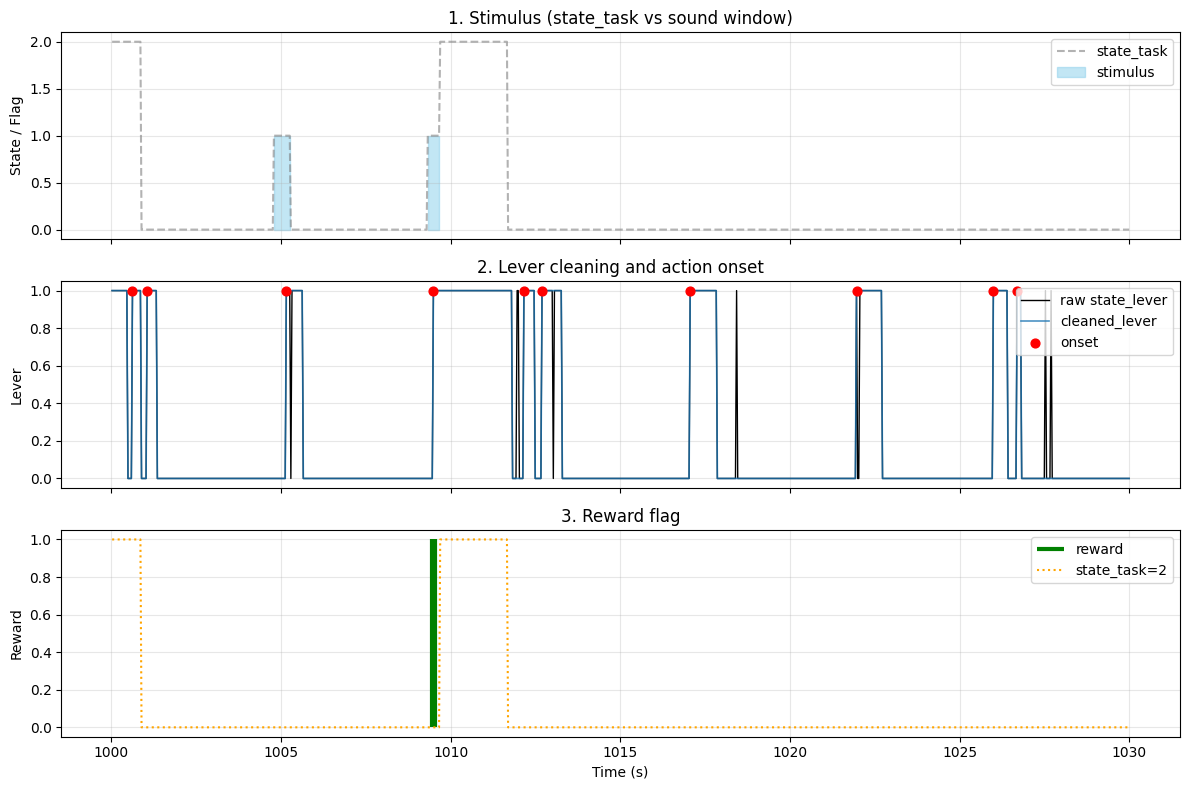

In [35]:
pack = v4.process_session(MOUSE_ID, INSPECT_DAY, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW)
cleaned = pack["cleaned"]
trials_one = pack["trials"]

print("cleaned frames:", len(cleaned))
print("raw lever 1s:", int(cleaned["state_lever"].sum()), " cleaned 1s:", int(cleaned["cleaned_lever"].sum()))
print("onsets:", int(cleaned["action"].sum()), " rewards:", int(cleaned["reward"].sum()))
print("face features:", "yes" if pack["has_face"] else "no (NWB が無いと 13 次元は後でスキップ)")

v4.plot_cleaning_validation(cleaned, start_time=1000, duration=30)


## 2. 試行抽出

公式の音提示試行（success / miss / failure）を Success / Short Pull / No Reaction に対応づけ、整形後 onset から Second Pull と No Sound Pull を足す。History は試行順で、当該試行の $y$ / Reward は使わない。


=== trial type counts ===
trial_type
No Sound Pull    335
Success           63
Short Pull        52
No Reaction       48
Name: count, dtype: int64

=== y / x_stim / reward by type (should match the spec table) ===
                 y  x_stim  reward
trial_type                        
No Reaction    0.0     1.0     0.0
No Sound Pull  1.0     0.0     0.0
Short Pull     1.0     1.0     0.0
Success        1.0     1.0     1.0
       trial_type    t_start      t_end    t_onset  y  x_stim  reward official_outcome  trial_index  x_bias    x_hist  x_rew  x_ear_pos  x_ear_spd  x_eye_pos  x_eye_spd  x_nose_pos  x_nose_spd  x_jaw_pos  x_jaw_spd   x_pupil  mouse_id    task_day
0   No Sound Pull   9.817200  10.817200   9.817200  1       0       0                             0     1.0  0.000000   0.00   0.000000   0.000000   0.000000   0.000000    0.000000    0.000000   0.000000   0.000000  0.000000  VG1GC-66  task-day15
1      Short Pull  14.884000  15.917200        NaN  1       1       0             

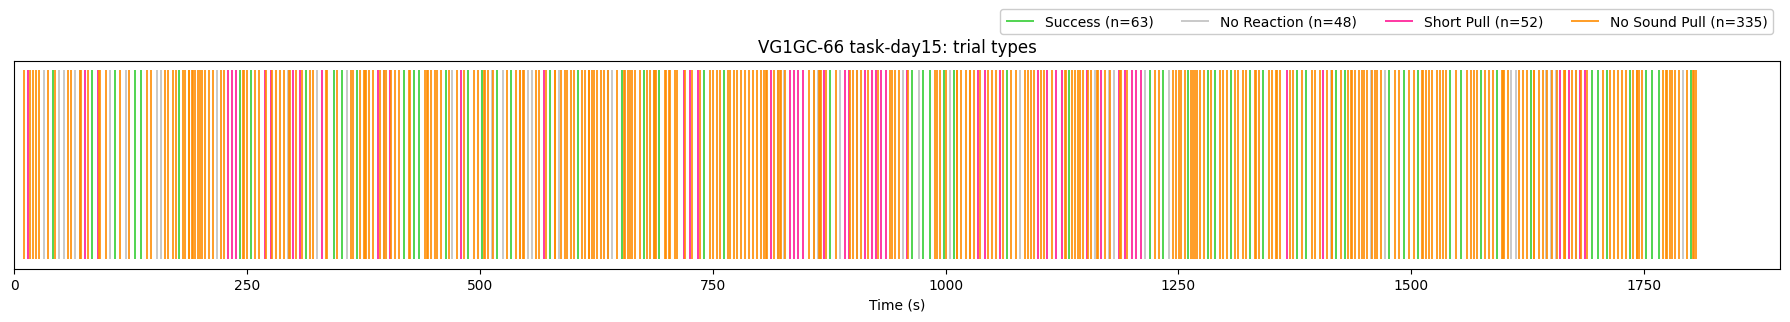

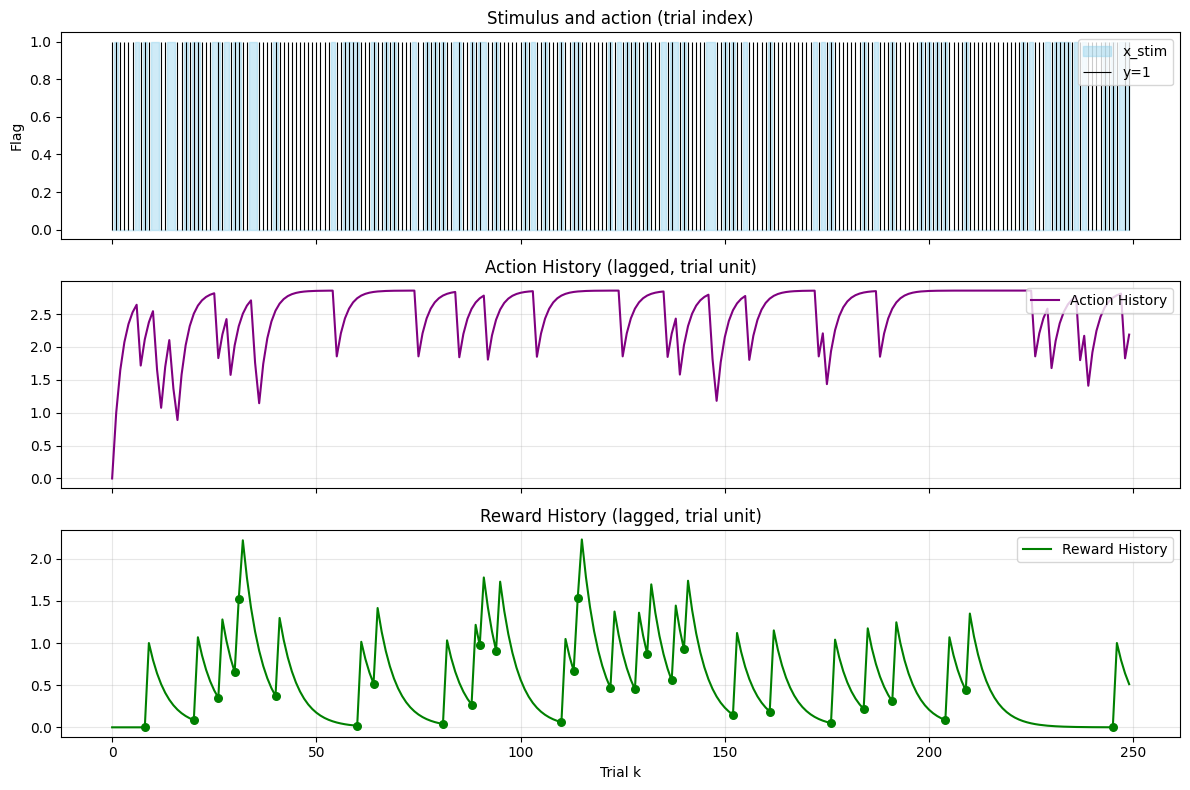

In [36]:
print("=== trial type counts ===")
print(trials_one["trial_type"].value_counts())
print("\n=== y / x_stim / reward by type (should match the spec table) ===")
print(trials_one.groupby("trial_type")[["y", "x_stim", "reward"]].mean())
print(trials_one.head(12).to_string())

v4.plot_trial_raster(trials_one, title=f"{MOUSE_ID} {INSPECT_DAY}: trial types")
v4.plot_history(trials_one, n_trials=min(250, len(trials_one)))


## 3. 個体の全日を系列化

各 `task-day` を ssm 用の1配列にする（ITI カットなし。試行列そのものが系列）。


CSV読み込み中: /content/drive/MyDrive/hackathon_data/VG1GC-66/task-day1/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /content/drive/MyDrive/nwb_manual/VG1GC-66/VG1GC-66_2023-09-08_task-day15.nwb
VG1GC-66 task-day1: 873 trials, face=yes
CSV読み込み中: /content/drive/MyDrive/hackathon_data/VG1GC-66/task-day3/trials_L1L2.csv
全試行数: 54000
VG1GC-66 task-day3: 548 trials, face=no
CSV読み込み中: /content/drive/MyDrive/hackathon_data/VG1GC-66/task-day4/trials_L1L2.csv
全試行数: 54000
VG1GC-66 task-day4: 470 trials, face=no
CSV読み込み中: /content/drive/MyDrive/hackathon_data/VG1GC-66/task-day5/trials_L1L2.csv
全試行数: 54000
VG1GC-66 task-day5: 376 trials, face=no
CSV読み込み中: /content/drive/MyDrive/hackathon_data/VG1GC-66/task-day6/trials_L1L2.csv
全試行数: 54000
VG1GC-66 task-day6: 375 trials, face=no
CSV読み込み中: /content/drive/MyDrive/hackathon_data/VG1GC-66/task-day7/trials_L1L2.csv
全試行数: 54000
VG1GC-66 task-day7: 386 trials, face=no
CSV読み込み中: /content/drive/MyDrive/hackathon_data/VG1GC-66/task-day8/trials_L1L2.csv
全試行数: 54000
VG1GC-

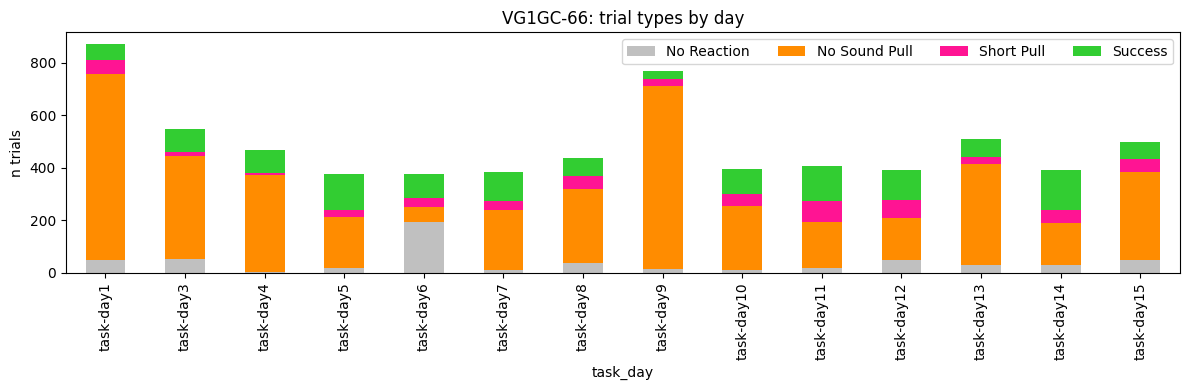

In [37]:
dataset = v4.process_mouse(MOUSE_ID, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW)
print("\n=== all days ===")
print("n sequences:", len(dataset["ys"]))
print("n trials:", len(dataset["trials"]))
print(dataset["trials"]["trial_type"].value_counts())
print("sessions with face:", dataset["n_with_face"], "/", len(dataset["ys"]))

counts = (
    dataset["trials"]
    .groupby(["task_day", "trial_type"])
    .size()
    .unstack(fill_value=0)
)
day_order = dataset["task_days"]
counts = counts.reindex(day_order)
ax = counts.plot(kind="bar", stacked=True, figsize=(12, 4), color=[v4.TRIAL_TYPE_COLORS.get(c, "gray") for c in counts.columns])
ax.set_ylabel("n trials")
ax.set_title(f"{MOUSE_ID}: trial types by day")
ax.legend(ncol=5, loc="upper right")
plt.tight_layout()
plt.show()


## 4. 学習 A: 行動 4 次元、K=3


Training GLM-HMM K=3 M=4 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-1083.11


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-1087.61


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-1083.09
Best log_prob=-1083.09


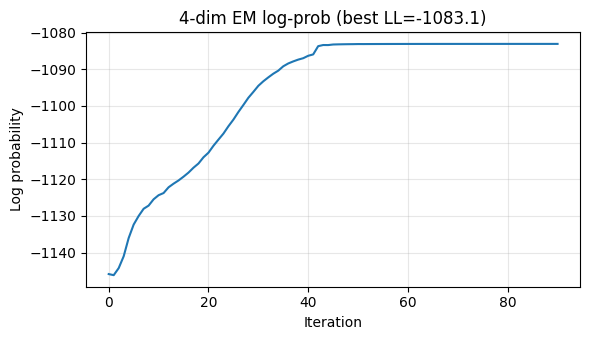

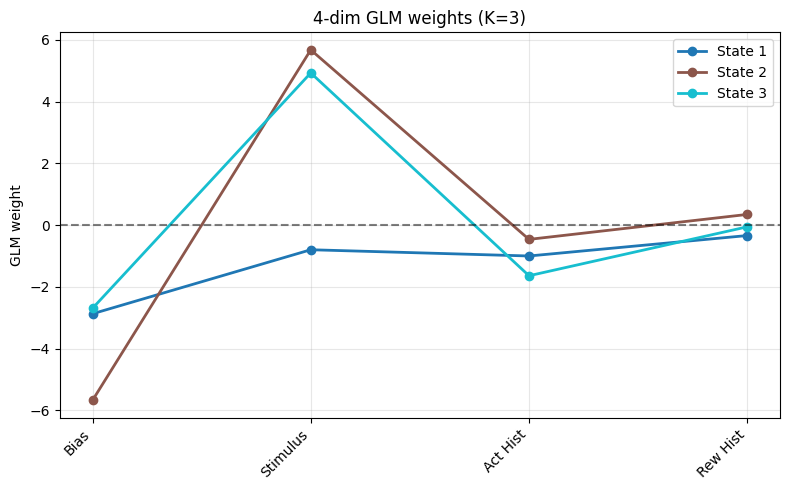

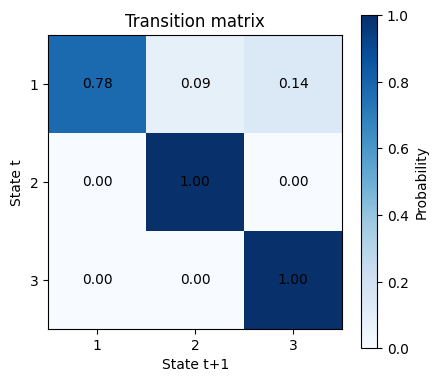

[[0.777 0.085 0.138]
 [0.    1.    0.   ]
 [0.    0.    1.   ]]


In [38]:
model4, lls4, ll4 = v4.train_glmhmm_map(
    dataset["ys"],
    dataset["xs4"],
    num_states=NUM_STATES,
    prior_sigma=PRIOR_SIGMA,
    num_iters=NUM_ITERS,
    seeds=SEEDS,
)
v4.plot_learning_curve(lls4, title=f"4-dim EM log-prob (best LL={ll4:.1f})")
v4.plot_glm_weights(model4, ["Bias", "Stimulus", "Act Hist", "Rew Hist"], title="4-dim GLM weights (K=3)")
trans4 = v4.plot_transition_matrix(model4)
print(np.round(trans4, 3))


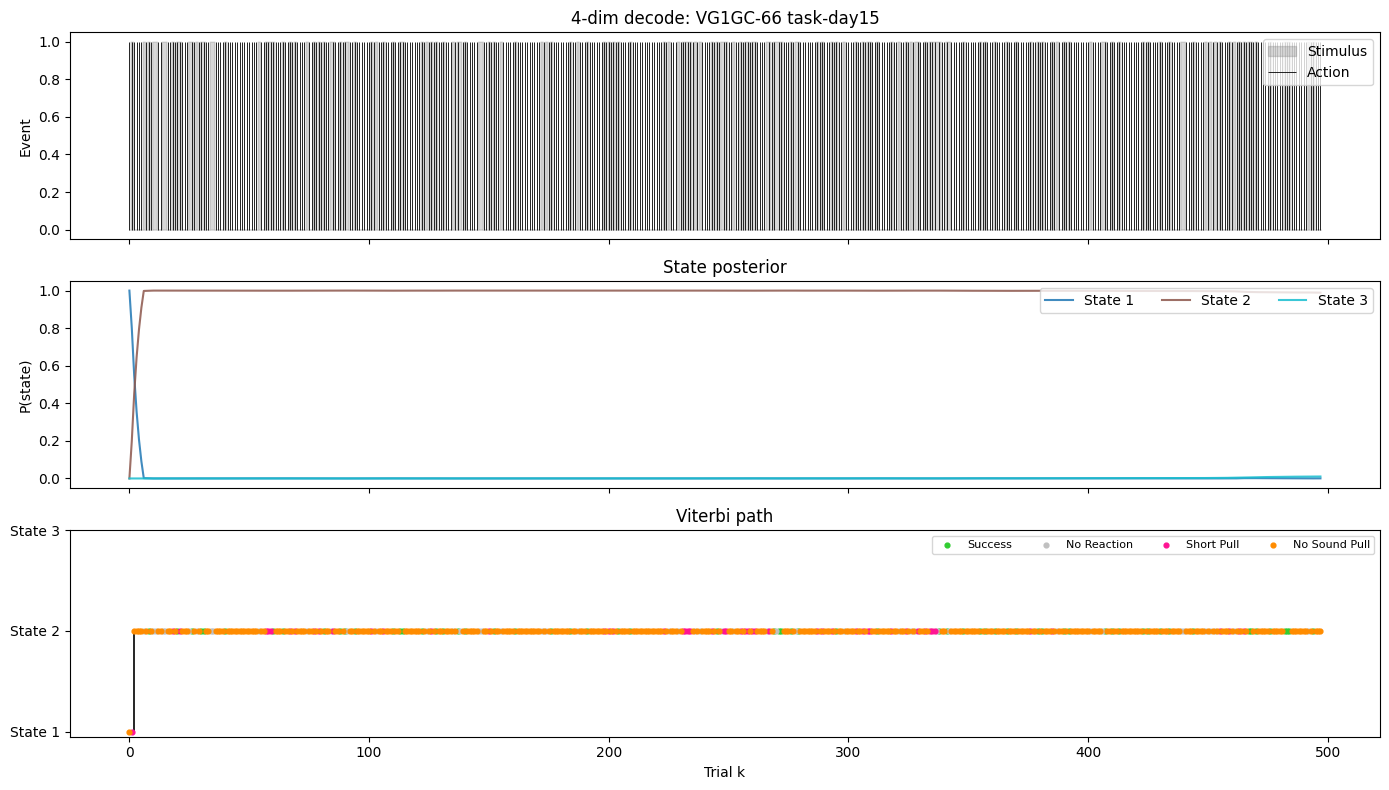

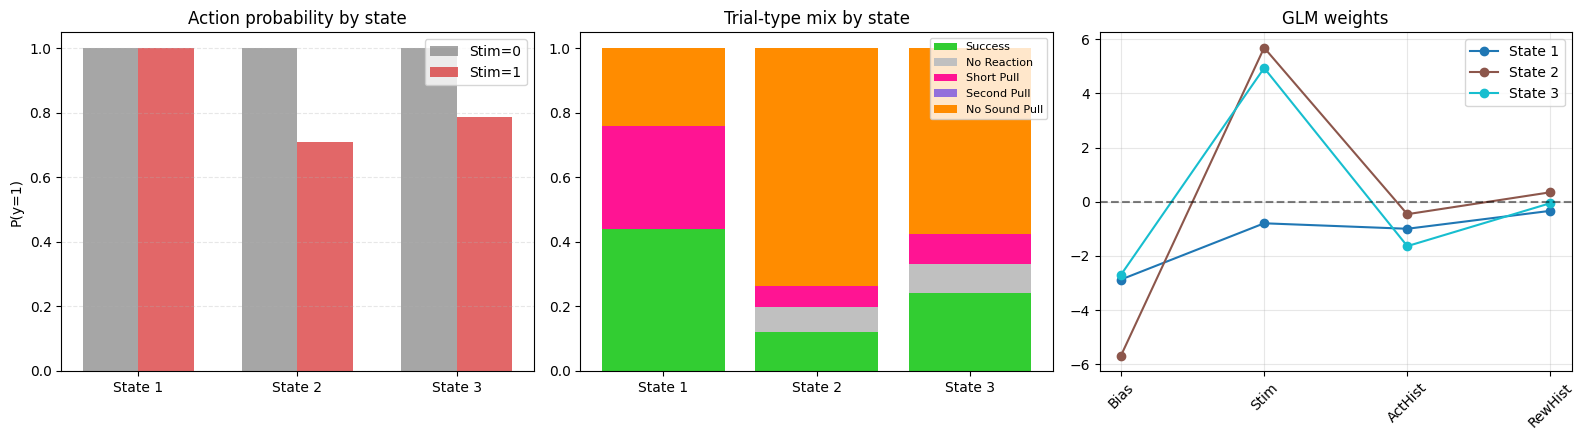

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 1.00
State 2 | Stim=0: 1.00  Stim=1: 0.71
State 3 | Stim=0: 1.00  Stim=1: 0.79


In [39]:
# 代表日の状態系列
day_idx = dataset["task_days"].index(INSPECT_DAY) if INSPECT_DAY in dataset["task_days"] else 0
day_trials = dataset["trials"][dataset["trials"]["task_day"] == dataset["task_days"][day_idx]]
v4.plot_state_path(
    model4,
    dataset["ys"][day_idx],
    dataset["xs4"][day_idx],
    trial_types=day_trials["trial_type"].to_numpy(),
    title=f"4-dim decode: {MOUSE_ID} {dataset['task_days'][day_idx]}",
)

decoded4 = v4.attach_decoded_states(dataset["trials"], *v4.decode_states(model4, dataset["ys"], dataset["xs4"]))
v4.plot_state_behavior(model4, decoded4, ["Bias", "Stim", "ActHist", "RewHist"])


## 5. 学習 B: 顔つき 13 次元、K=3

NWB の `entries` から顔特徴が取れたセッションだけで学習する。4 次元と同じ K=3・同じ α・同じ MAP 正則化。


13-dim sessions: ['task-day1', 'task-day15']
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-262.25


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-259.91


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-262.26
Best log_prob=-259.91


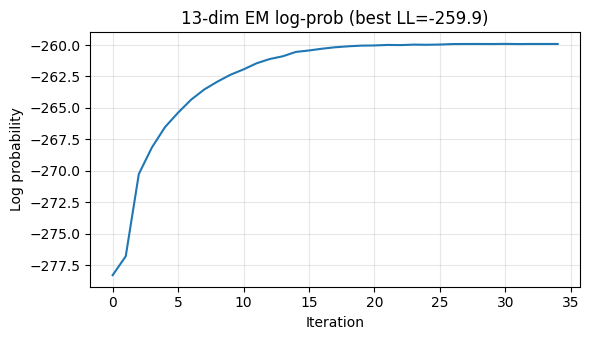

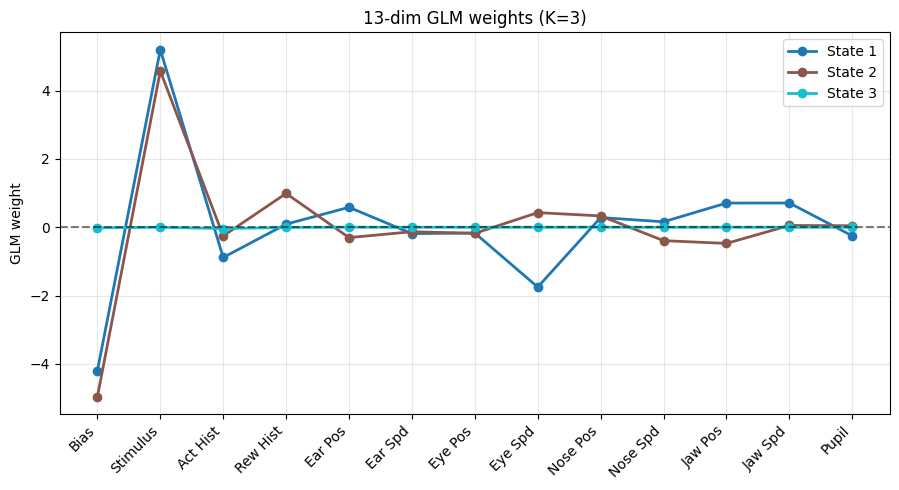

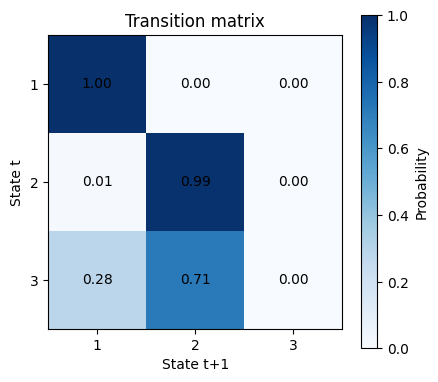

[[0.996 0.004 0.   ]
 [0.012 0.988 0.   ]
 [0.282 0.715 0.004]]


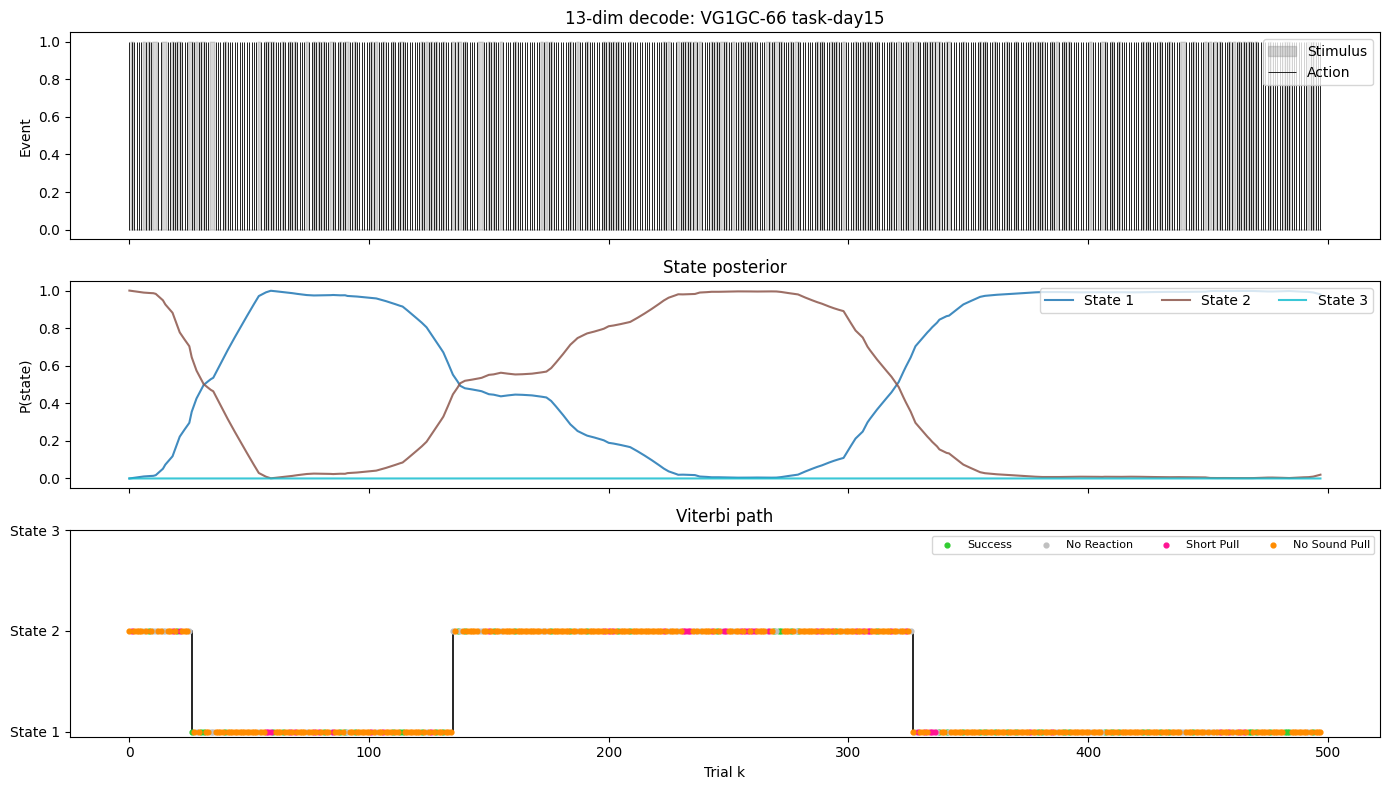

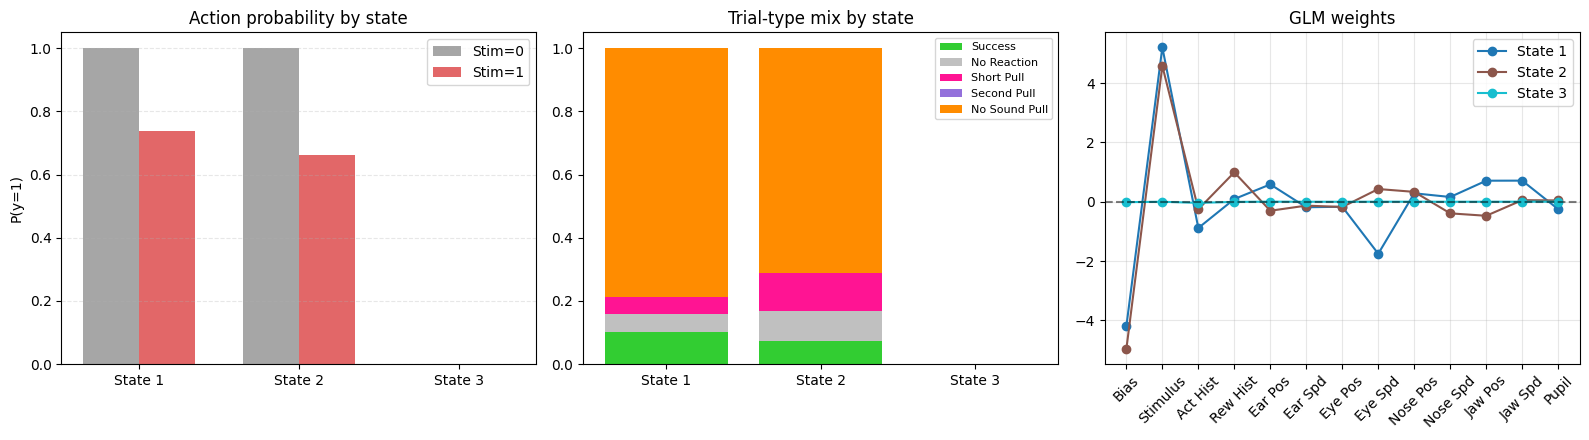

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.74
State 2 | Stim=0: 1.00  Stim=1: 0.66
State 3 | Stim=0: 0.00  Stim=1: 0.00


In [40]:
FACE_NAMES = [
    "Bias", "Stimulus", "Act Hist", "Rew Hist",
    "Ear Pos", "Ear Spd", "Eye Pos", "Eye Spd",
    "Nose Pos", "Nose Spd", "Jaw Pos", "Jaw Spd",
    "Pupil",
]

face_idx = [i for i, s in enumerate(dataset["sessions"]) if s["has_face"]]
if not face_idx:
    print("顔特徴付きセッションが無いので 13 次元学習をスキップします。")
    print("NWB が DATA_NWB_ROOT に見える環境（Colab 等）で再実行してください。")
    model13 = None
    decoded13 = None
else:
    ys13 = [dataset["ys"][i] for i in face_idx]
    xs13 = [dataset["xs13"][i] for i in face_idx]
    days13 = [dataset["task_days"][i] for i in face_idx]
    print(f"13-dim sessions: {days13}")
    model13, lls13, ll13 = v4.train_glmhmm_map(
        ys13, xs13,
        num_states=NUM_STATES,
        prior_sigma=PRIOR_SIGMA,
        num_iters=NUM_ITERS,
        seeds=SEEDS,
    )
    v4.plot_learning_curve(lls13, title=f"13-dim EM log-prob (best LL={ll13:.1f})")
    v4.plot_glm_weights(model13, FACE_NAMES, title="13-dim GLM weights (K=3)")
    trans13 = v4.plot_transition_matrix(model13)
    print(np.round(trans13, 3))

    d0 = 0
    if INSPECT_DAY in days13:
        d0 = days13.index(INSPECT_DAY)
    trials13 = dataset["trials"][dataset["trials"]["task_day"].isin(days13)]
    day_trials13 = trials13[trials13["task_day"] == days13[d0]]
    v4.plot_state_path(
        model13, ys13[d0], xs13[d0],
        trial_types=day_trials13["trial_type"].to_numpy(),
        title=f"13-dim decode: {MOUSE_ID} {days13[d0]}",
    )
    decoded13 = v4.attach_decoded_states(trials13, *v4.decode_states(model13, ys13, xs13))
    v4.plot_state_behavior(model13, decoded13, FACE_NAMES)


## 6. 4 次元と 13 次元の比較

顔が載ったセッションだけで、両モデルの平均対数尤度（試行あたり）を比べる。状態の対応は自動では揃わないので、重みの形と試行タイプ構成で読む。


n trials used for comparison: 1371
4-dim  mean loglik / trial: -0.1470  (total -201.6)
13-dim mean loglik / trial: -0.1348  (total -184.8)


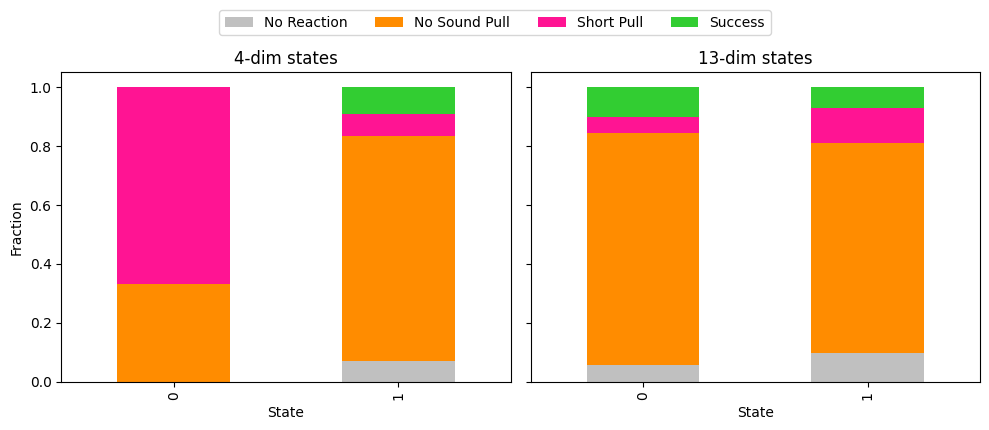

In [41]:
def mean_ll(model, ys, xs):
    total = 0.0
    n = 0
    for y, x in zip(ys, xs):
        if hasattr(model, "log_likelihood"):
            total += float(model.log_likelihood(y, inputs=x))
        else:
            total += float(np.sum(model.log_probability(y, inputs=x)))
        n += len(y)
    return total / max(n, 1), total, n

if model13 is None:
    print("13 次元モデルが無いので比較をスキップします。")
else:
    ll4_per, ll4_tot, n4 = mean_ll(model4, ys13, [dataset["xs4"][i] for i in face_idx])
    ll13_per, ll13_tot, n13 = mean_ll(model13, ys13, xs13)
    print(f"n trials used for comparison: {n13}")
    print(f"4-dim  mean loglik / trial: {ll4_per:.4f}  (total {ll4_tot:.1f})")
    print(f"13-dim mean loglik / trial: {ll13_per:.4f}  (total {ll13_tot:.1f})")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for ax, decoded, title in [
        (axes[0], decoded4[decoded4["task_day"].isin(days13)], "4-dim states"),
        (axes[1], decoded13, "13-dim states"),
    ]:
        tab = decoded.groupby(["state", "trial_type"]).size().unstack(fill_value=0)
        tab = tab.div(tab.sum(axis=1), axis=0)
        tab.plot(
            kind="bar", stacked=True, ax=ax,
            color=[v4.TRIAL_TYPE_COLORS.get(c, "gray") for c in tab.columns],
            legend=False,
        )
        ax.set_title(title)
        ax.set_xlabel("State")
        ax.set_ylabel("Fraction")
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.08))
    plt.tight_layout()
    plt.show()
